In [1]:
%load_ext autoreload
%autoreload 2

In [195]:
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd

from rewards import sample_children_with_corr
from agent import social_generalization, value_fusion_icm, value_shaping

In [37]:
seed = 42
rng: np.random.Generator = np.random.default_rng(seed)

In [38]:
rho_child_child = 0.6
_, child_maps = sample_children_with_corr(
            rng=rng,
            n_children=4,
            length_scale=2.0,
            rho_parent_child=rho_child_child,
            rho_child_child=rho_child_child,
            tol=0.1,
            max_tries=1000,
            grid_size=11
        )

In [58]:
X = np.arange(11)
rewards_1 = child_maps[0].mean(axis=1)
rewards_1 =  (rewards_1 - rewards_1.min()) / (rewards_1.max() - rewards_1.min())
rewards_2 = child_maps[1].mean(axis=1)
rewards_2 = (rewards_2 - rewards_2.min()) / (rewards_2.max() - rewards_2.min())

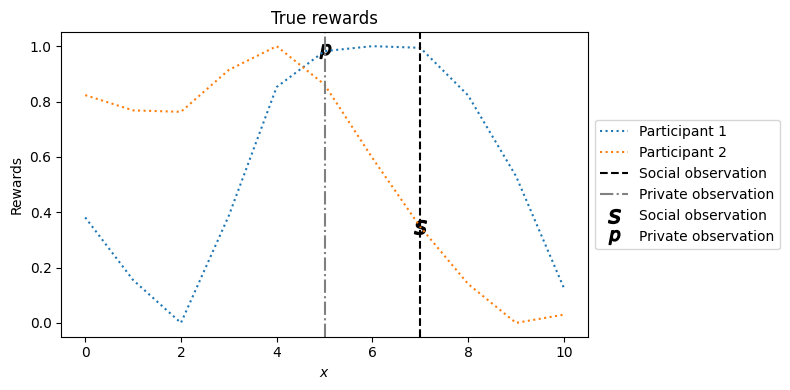

In [119]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(X, rewards_1, label="Participant 1", linestyle="dotted")
ax.plot(X, rewards_2, label="Participant 2", linestyle="dotted")

social_observations_X = 7
social_observations_y = rewards_2[social_observations_X]

private_observations_X = 5
private_observations_y = rewards_1[priveate_observations_X]

ax.axvline(social_observations_X, color="k", linestyle="--", linewidth=1.5, label="Social observation")
ax.axvline(private_observations_X, color="gray", linestyle="-.", linewidth=1.5, label="Private observation")

ax.scatter(
    social_observations_X, social_observations_y, 
    label="Social observation", marker="$s$", color="k", s=100
)
ax.scatter(
    private_observations_X, private_observations_y, 
    label="Private observation", marker="$p$", color="k", s=100
)

ax.set_xlabel("$x$")
ax.set_ylabel("Rewards")
ax.set_title("True rewards")


ax.legend(
    loc="center left", 
    bbox_to_anchor=(1, 0.5),
    frameon=True
)

plt.tight_layout()
plt.show()

### SG model

In [196]:
soc_noise_mult = [1, 100, 1000, 10_000]
sg_preditions = []
for s_n in soc_noise_mult:
    prediction = social_generalization(
        X_obs_private=np.array([[private_observations_X]]),
        y_obs_private=np.array([[private_observations_y]]),
        X_obs_social=[np.array([[social_observations_X]])],
        y_obs_social=[np.array([[social_observations_y]])],
        X_predict=X.reshape(-1, 1),
        length_scale=2.0,
        observation_noise_private=0.001,
        observation_noise_social=0.001 * s_n,
        beta=0.5,
        tau=1,
        random_state=rng.__getstate__()
    )
    sg_preditions.append(prediction)

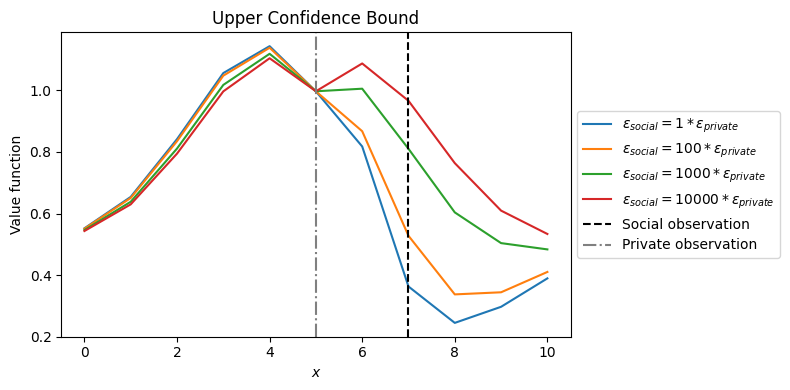

In [197]:
fig, ax = plt.subplots(figsize=(8, 4))

for i, s_n in enumerate(soc_noise_mult):
    ax.plot(X, np.log(sg_preditions[i]), label=fr"$\epsilon_{{social}}={s_n}*\epsilon_{{private}}$")

ax.axvline(social_observations_X, color="k", linestyle="--", linewidth=1.5, label="Social observation")
ax.axvline(private_observations_X, color="gray", linestyle="-.", linewidth=1.5, label="Private observation")

ax.set_xlabel("$x$")
ax.set_ylabel("Value function")
ax.set_title("Upper Confidence Bound")



ax.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=True
)

plt.tight_layout()
plt.show()

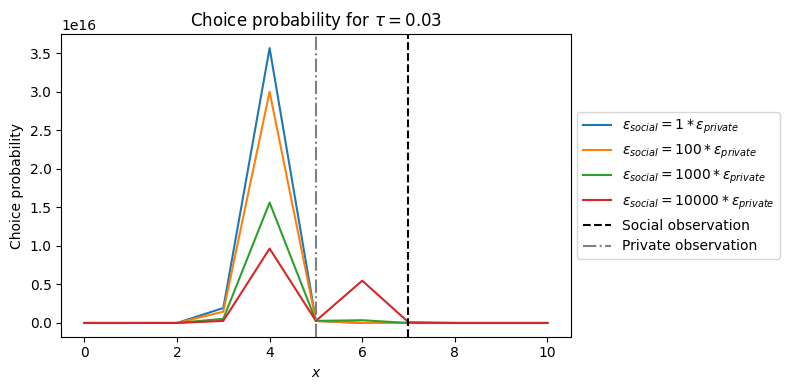

In [230]:
fig, ax = plt.subplots(figsize=(8, 4))

for i, s_n in enumerate(soc_noise_mult):
    prob = np.exp(np.log(sg_preditions[i]) / 0.03)
    # prob /= prob.max()
    ax.plot(X, prob, label=fr"$\epsilon_{{social}}={s_n}*\epsilon_{{private}}$")

ax.axvline(social_observations_X, color="k", linestyle="--", 
           linewidth=1.5, label="Social observation")
ax.axvline(private_observations_X, color="gray", linestyle="-.", 
           linewidth=1.5, label="Private observation")

ax.set_xlabel("$x$")
ax.set_ylabel("Choice probability")
ax.set_title(r"Choice probability for $\tau=0.03$")

ax.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=True
)

plt.tight_layout()
plt.show()

## ICM model

In [224]:
rhos = [0, 0.5, 0.75, 1]
icm_preditions = []
for rho in rhos[::-1]:
    prediction = value_fusion_icm(
        X_obs_private=np.array([[private_observations_X]]),
        y_obs_private=np.array([[private_observations_y]]),
        X_obs_social=[np.array([[social_observations_X]])],
        y_obs_social=[np.array([[social_observations_y]])],
        X_predict=X.reshape(-1, 1),
        length_scale_private=2.0,
        length_scale_social=2.0,
        length_scale_is_identical=True,
        observation_noise_private=0.001,
        observation_noise_social=0.001,
        rho=rho,
        beta=0.5,
        tau=1,
        random_state=rng.__getstate__()
    )
    icm_preditions.append(prediction)

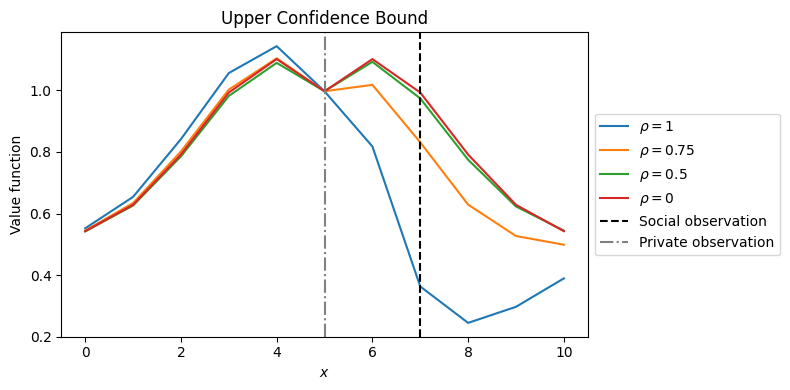

In [225]:
fig, ax = plt.subplots(figsize=(8, 4))

for i, rho in enumerate(rhos[::-1]):
    ax.plot(X, np.log(icm_preditions[i]), label=fr"$\rho={rho}$")

ax.axvline(social_observations_X, color="k", linestyle="--", linewidth=1.5, label="Social observation")
ax.axvline(private_observations_X, color="gray", linestyle="-.", linewidth=1.5, label="Private observation")

ax.set_xlabel("$x$")
ax.set_ylabel("Value function")
ax.set_title("Upper Confidence Bound")



ax.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=True
)

plt.tight_layout()
plt.show()

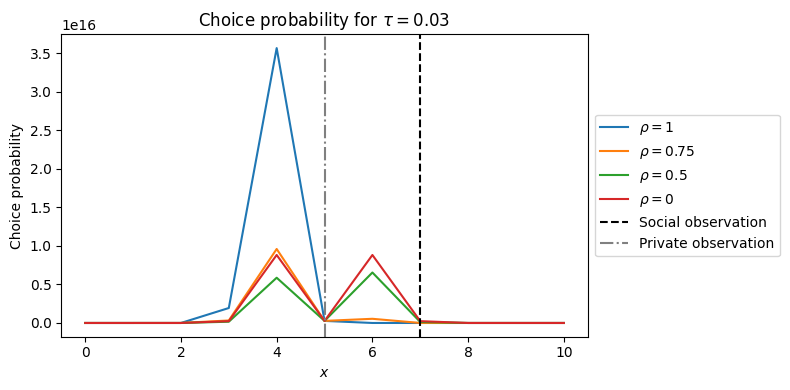

In [227]:
fig, ax = plt.subplots(figsize=(8, 4))

for i, rho in enumerate(rhos[::-1]):
    prob = np.exp(np.log(icm_preditions[i]) / 0.03)
    # prob /= prob.max()
    ax.plot(X, prob, label=fr"$\rho={rho}$")


ax.axvline(social_observations_X, color="k", linestyle="--", 
           linewidth=1.5, label="Social observation")
ax.axvline(private_observations_X, color="gray", linestyle="-.", 
           linewidth=1.5, label="Private observation")

ax.set_xlabel("$x$")
ax.set_ylabel("Choice probability")
ax.set_title(r"Choice probability for $\tau=0.03$")

ax.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=True
)

plt.tight_layout()
plt.show()

## $\alpha$ Value Shaping

In [244]:
alphas = [0, 0.25, 0.5, 0.75, 1]
value_shaping_preditions = []
for alpha in alphas[::-1]:
    prediction = value_shaping(
        X_obs_private=np.array([[private_observations_X]]),
        y_obs_private=np.array([[private_observations_y]]),
        X_obs_social=[np.array([[social_observations_X]])],
        y_obs_social=[np.array([[social_observations_y]])],
        X_predict=X.reshape(-1, 1),
        length_scale_private=2.0,
        length_scale_social=2.0,
        observation_noise_private=0.001,
        observation_noise_social=0.001,
        alpha=alpha,
        beta_private=0.5,
        beta_social=0.5,
        tau=1,
        random_state=rng.__getstate__(),
        value_shaping_type="linear_weight"
    )
    # prediction /= prediction.max()
    value_shaping_preditions.append(prediction)

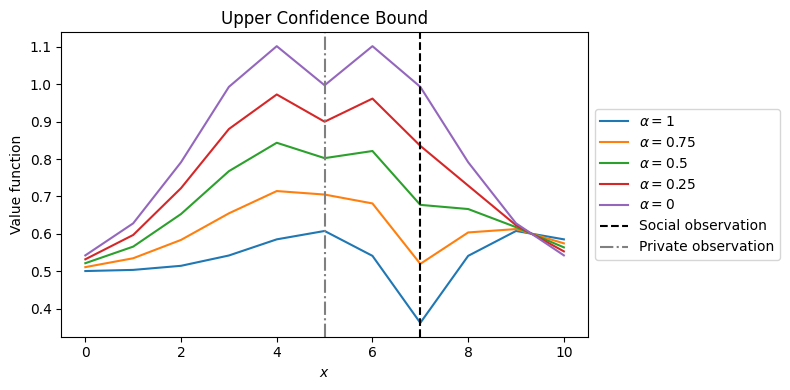

In [245]:
fig, ax = plt.subplots(figsize=(8, 4))

for i, alpha in enumerate(alphas[::-1]):
    ax.plot(X, np.log(value_shaping_preditions[i]), label=fr"$\alpha={alpha}$")

ax.axvline(social_observations_X, color="k", linestyle="--", linewidth=1.5, label="Social observation")
ax.axvline(private_observations_X, color="gray", linestyle="-.", linewidth=1.5, label="Private observation")

ax.set_xlabel("$x$")
ax.set_ylabel("Value function")
ax.set_title("Upper Confidence Bound")



ax.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=True
)

plt.tight_layout()
plt.show()

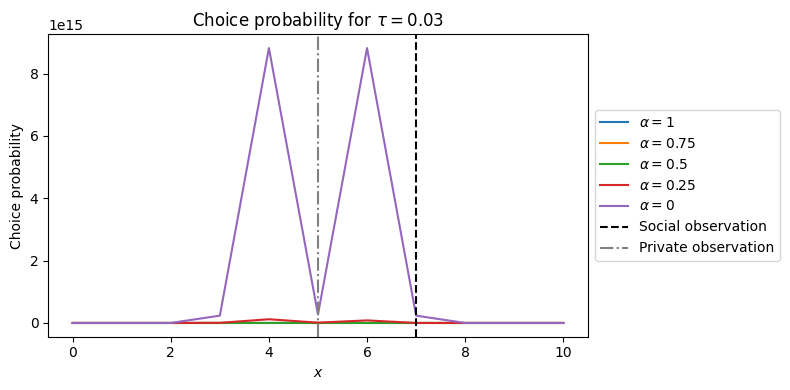

In [246]:
fig, ax = plt.subplots(figsize=(8, 4))

for i, alpha in enumerate(alphas[::-1]):
    prob = np.exp(np.log(value_shaping_preditions[i]) / 0.03)
    # prob /= prob.max()
    ax.plot(X, prob, label=fr"$\alpha={alpha}$")


ax.axvline(social_observations_X, color="k", linestyle="--", 
           linewidth=1.5, label="Social observation")
ax.axvline(private_observations_X, color="gray", linestyle="-.", 
           linewidth=1.5, label="Private observation")

ax.set_xlabel("$x$")
ax.set_ylabel("Choice probability")
ax.set_title(r"Choice probability for $\tau=0.03$")

ax.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=True
)

plt.tight_layout()
plt.show()

## Correlated Kalman Value Shaping

In [258]:
alphas = [0, 0.25, 0.5, 0.75, 1]
value_shaping_preditions_ck = []
for alpha in alphas[::-1]:
    prediction = value_shaping(
        X_obs_private=np.array([[private_observations_X]]),
        y_obs_private=np.array([[private_observations_y]]),
        X_obs_social=[np.array([[social_observations_X]])],
        y_obs_social=[np.array([[social_observations_y]])],
        X_predict=X.reshape(-1, 1),
        length_scale_private=2.0,
        length_scale_social=2.0,
        observation_noise_private=0.001,
        observation_noise_social=0.001,
        alpha=alpha,
        beta_private=0.5,
        beta_social=0.5,
        tau=1,
        random_state=rng.__getstate__(),
        value_shaping_type="correlated_kalman"
    )
    # prediction /= prediction.max()
    value_shaping_preditions_ck.append(prediction)

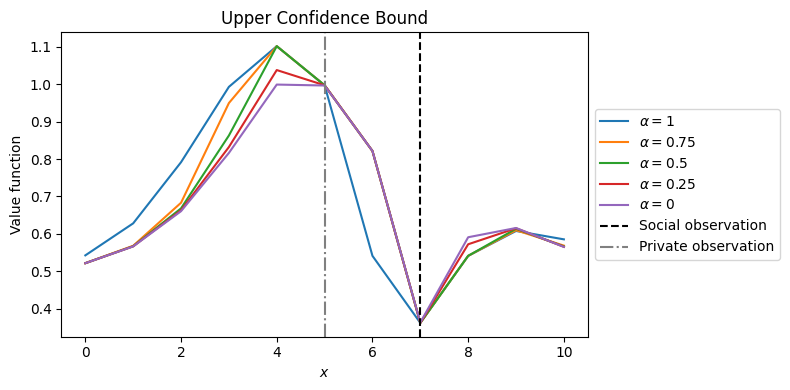

In [259]:
fig, ax = plt.subplots(figsize=(8, 4))

for i, alpha in enumerate(alphas[::-1]):
    ax.plot(X, np.log(value_shaping_preditions_ck[i]), label=fr"$\alpha={alpha}$")

ax.axvline(social_observations_X, color="k", linestyle="--", linewidth=1.5, label="Social observation")
ax.axvline(private_observations_X, color="gray", linestyle="-.", linewidth=1.5, label="Private observation")

ax.set_xlabel("$x$")
ax.set_ylabel("Value function")
ax.set_title("Upper Confidence Bound")



ax.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=True
)

plt.tight_layout()
plt.show()

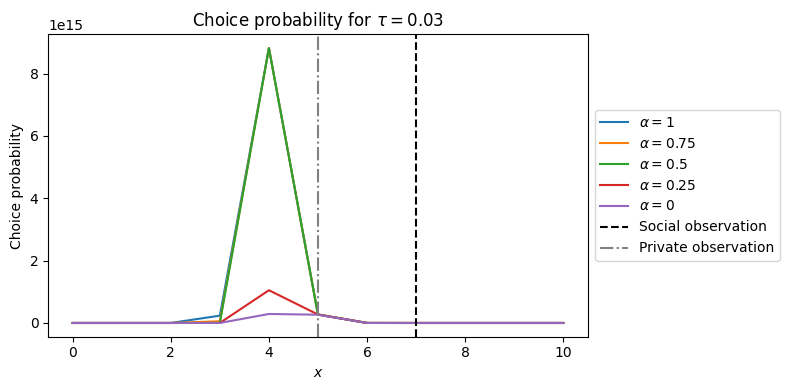

In [260]:
fig, ax = plt.subplots(figsize=(8, 4))

for i, alpha in enumerate(alphas[::-1]):
    prob = np.exp(np.log(value_shaping_preditions_ck[i]) / 0.03)
    # prob /= prob.max()
    ax.plot(X, prob, label=fr"$\alpha={alpha}$")


ax.axvline(social_observations_X, color="k", linestyle="--", 
           linewidth=1.5, label="Social observation")
ax.axvline(private_observations_X, color="gray", linestyle="-.", 
           linewidth=1.5, label="Private observation")

ax.set_xlabel("$x$")
ax.set_ylabel("Choice probability")
ax.set_title(r"Choice probability for $\tau=0.03$")

ax.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=True
)

plt.tight_layout()
plt.show()